In [1]:
# import numpy as np
# import itertools
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# import scipy as sp
# from scipy.stats import linregress, pearsonr, spearmanr, norm
# from sklearn.metrics import roc_curve, auc
# import time
# import distinctipy

# from glob import glob
# import re

# import pickle as pkl
# import sys
# import os
# import gc

# current_dir = os.getcwd()
# parent_dir = os.path.dirname(current_dir)
# sys.path.append(parent_dir)
# from nsm.nsm import *

# params = {'legend.fontsize': 15,
#           'figure.figsize': (7, 7),
#           'axes.labelsize': 20,
#           'axes.titlesize': 20,
#           'axes.linewidth': 3,
#           'xtick.labelsize': 18,
#           'ytick.labelsize': 18,
#           'svg.fonttype': 'none'}
# plt.rcParams.update(params)
# np.random.seed(12345)

# mediators_ = {
#     'mediators1': ['R01'],
#     'mediators2': ['R09'],
#     'mediators3': ['R01', 'R05'],
#     'mediators4': ['R01', 'R13'],
#     'mediators5': ['R01', 'R03', 'R07', 'R10', 'R13'],
#     'mediators6': ['R01', 'R03', 'R05', 'R07', 'R08', 'R09', 'R10', 'R12', 'R13', 'R15'],
#     'mediators7': ['R01', 'R02', 'R03', 'R04', 'R05', 'R06', 'R07', 'R08', 'R09', 'R10', 'R11', 'R12', 'R13', 'R14', 'R15']
# }

# col_names = [
#     'species',
#     'resources',
#     'complexity',
#     'mediators',
#     'case',
#     'experiments',
#     'k',
#     'variable',
#     'type',
#     'correlation'
# ]

# # Ensure the file exists
# if not os.path.exists('correlations.csv'):
#     raise FileNotFoundError("The file 'correlations.csv' does not exist in the current directory.")

# correlations = pd.read_csv('correlations.csv', header=None, names=col_names)

# for var_type in ['S', 'R']:
#     for species_num in [12, 30, 50]:
#         for complexity in ['base', 'simple', 'intricate']:
#             for md in ['mediators1', 'mediators2', 'mediators3', 'mediators4', 'mediators5', 'mediators6', 'mediators7']:
#                 to_plot = correlations[
#                     (correlations['species'] == species_num) &
#                     (correlations['mediators'] == md) &
#                     (correlations['variable'].str.contains(var_type))
#                 ].copy()
#                 if to_plot.empty:
#                     print(f"No data for species {species_num}, mediators {md}, variable type {var_type}.")
#                     continue
#                 g = sns.relplot(
#                     data=to_plot,
#                     x='experiments',
#                     y='correlation',
#                     hue='k',
#                     palette='Set1',
#                     col='case',
#                     col_order=['baseline', 'sparse', 'noisy'],
#                     markers='o',
#                     kind='line',
#                 )

#                 # Include supertitle
#                 g.fig.suptitle(
#                     f'{species_num} species | {md} | {complexity} complexity | variable type: {"Species" if var_type == "S" else "Mediators"}',
#                     fontsize=24,
#                     y=1.05,
#                 )

#                 # Customize column labels
#                 g.set_titles(col_template="{col_name}")
#                 g.set_axis_labels('# experiments', 'Correlation (r)')

#                 # Save the plot
#                 plot_filename = f'plots/performance/correlation_{species_num}s_{complexity}_{md}_{var_type}.png'
#                 os.makedirs(os.path.dirname(plot_filename), exist_ok=True)
#                 g.savefig(plot_filename, dpi=300, bbox_inches='tight')
#                 plt.close()

#                 # Clean up
#                 del g
#                 gc.collect()

### Prediction performance

In [31]:
import numpy as np
import itertools
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
from scipy.stats import linregress, pearsonr, spearmanr, norm
from sklearn.metrics import roc_curve, auc
import time
import distinctipy

from glob import glob
import re

import pickle as pkl
import sys
import os
import gc

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)
from nsm.nsm import *

params = {'legend.fontsize': 15,
          'figure.figsize': (7, 7),
          'axes.labelsize': 20,
          'axes.titlesize': 20,
          'axes.linewidth': 3,
          'xtick.labelsize': 18,
          'ytick.labelsize': 18,
          'svg.fonttype': 'none'}
plt.rcParams.update(params)
np.random.seed(12345)

mediators_ = {
    'mediators1': ['R01'],
    'mediators2': ['R09'],
    'mediators3': ['R01', 'R05'],
    'mediators4': ['R01', 'R13'],
    'mediators5': ['R01', 'R03', 'R07', 'R10', 'R13'],
    'mediators6': ['R01', 'R03', 'R05', 'R07', 'R08', 'R09', 'R10', 'R12', 'R13', 'R15'],
    'mediators7': ['R01', 'R02', 'R03', 'R04', 'R05', 'R06', 'R07', 'R08', 'R09', 'R10', 'R11', 'R12', 'R13', 'R14', 'R15']
}

col_names = [
    'species',
    'resources',
    'complexity',
    'mediators',
    'case',
    'experiments',
    'k',
    'variable',
    'type',
    'correlation'
]

# Ensure the file exists
if not os.path.exists('correlations.csv'):
    raise FileNotFoundError("The file 'correlations.csv' does not exist in the current directory.")

correlations = pd.read_csv('correlations.csv', header=None, names=col_names, index_col=False)
# remove duplicated rows
correlations = correlations.drop_duplicates()

for var_type in ['S', 'R']:
    for species_num in [12, 30, 50]:
        for complexity in ['base', 'simple', 'intricate']:
            to_plot = correlations[
                (correlations['species'] == species_num) &
                (correlations['complexity'] == complexity) &
                (correlations['variable'].str.contains(var_type))
            ].copy()
            if to_plot.empty:
                print(f"No data for species {species_num}, variable type {var_type}, complexity {complexity}.")
                continue

            # Ensure the order of mediators
            mediator_order = [f'mediators{i}' for i in range(1, 8)]
            to_plot['mediators'] = pd.Categorical(to_plot['mediators'], categories=mediator_order, ordered=True)

            g = sns.relplot(
                data=to_plot,
                x='experiments',
                y='correlation',
                hue='mediators',
                style='k',
                dashes=[(1, 0)],
                palette='Set1',
                col='case',
                col_order=['baseline', 'sparse', 'noisy'],
                kind='line',
            )

            # Include supertitle
            g.fig.suptitle(
                f'{species_num} species | {complexity} complexity | variable type: {"Species" if var_type == "S" else "Mediators"}',
                fontsize=24,
                y=1.05,
            )

            # Customize column labels
            g.set_titles(col_template="{col_name}")
            g.set_axis_labels('# experiments', 'Correlation (r)')

            # Save the plot
            plot_filename = f'plots/performance/predictions/correlation_{species_num}s_{complexity}_{var_type}.png'
            os.makedirs(os.path.dirname(plot_filename), exist_ok=True)
            g.savefig(plot_filename, dpi=300, bbox_inches='tight')
            plt.close()

            # Clean up
            del g
            gc.collect()

/tmp/ipykernel_97455/653058163.py:83: UserWarning: 
The dashes list has fewer values (1) than needed (5) and will cycle, which may produce an uninterpretable plot.
  g = sns.relplot(
/tmp/ipykernel_97455/653058163.py:83: UserWarning: 
The dashes list has fewer values (1) than needed (5) and will cycle, which may produce an uninterpretable plot.
  g = sns.relplot(
/tmp/ipykernel_97455/653058163.py:83: UserWarning: 
The dashes list has fewer values (1) than needed (5) and will cycle, which may produce an uninterpretable plot.
  g = sns.relplot(
/tmp/ipykernel_97455/653058163.py:83: UserWarning: 
The dashes list has fewer values (1) than needed (5) and will cycle, which may produce an uninterpretable plot.
  g = sns.relplot(
/tmp/ipykernel_97455/653058163.py:83: UserWarning: 
The dashes list has fewer values (1) than needed (5) and will cycle, which may produce an uninterpretable plot.
  g = sns.relplot(
/tmp/ipykernel_97455/653058163.py:83: UserWarning: 
The dashes list has fewer values 

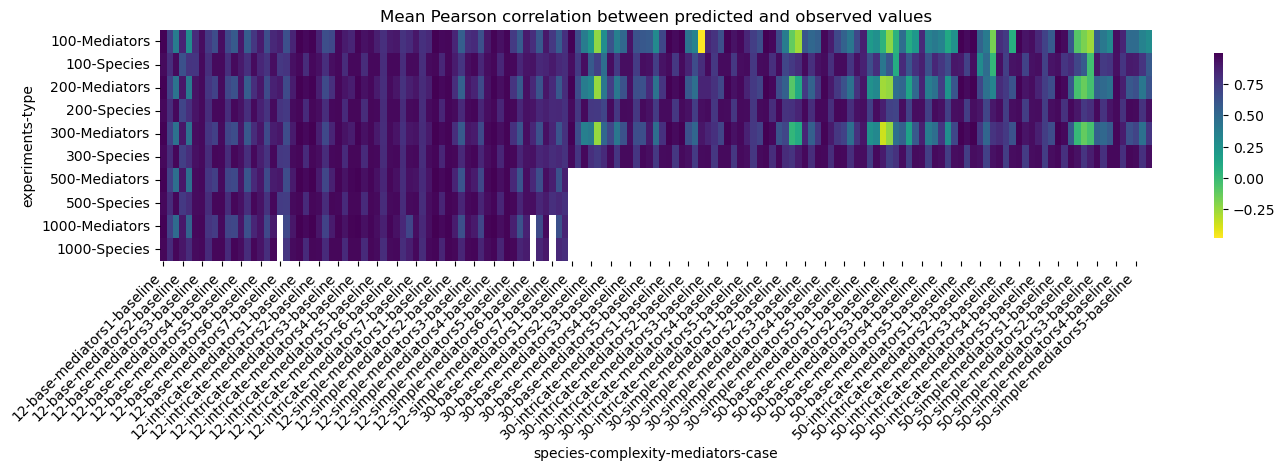

experiments                                 100                 200   \
type                                   Mediators   Species Mediators   
species complexity mediators  case                                     
12      base       mediators1 baseline  0.983346  0.955486  0.984469   
                              noisy     0.707123  0.802544  0.706939   
                              sparse    0.382625  0.957332  0.435969   
                   mediators2 baseline  0.852533  0.630567  0.903725   
                              noisy     0.277212  0.770799  0.393980   
...                                          ...       ...       ...   
50      simple     mediators4 noisy     0.846453  0.765248  0.867890   
                              sparse    0.484784  0.894625  0.595361   
                   mediators5 baseline  0.483761  0.880572  0.635362   
                              noisy     0.346519  0.772281  0.412190   
                              sparse    0.287720  0.582415  0.628058   

experiments                                           300             \
type                                     Species Mediators   Species   
species complexity mediators  case                                     
12      base       mediators1 baseline  0.959435  0.984954  0.961621   
                              noisy     0.807607  0.707943  0.810620   
                              sparse    0.964000  0.452837  0.965890   
                   mediators2 baseline  0.691308  0.903296  0.723063   
                              noisy     0.794431  0.453998  0.801627   
...                                          ...       ...       ...   
50      simple     mediators4 noisy     0.785567  0.879087  0.789315   
                              sparse    0.962758  0.632375  0.967326   
                   mediators5 baseline  0.953920  0.697990  0.956747   
                              noisy     0.783693  0.447374  0.788198   
                              sparse    0.936911  0.763891  0.944303   

experiments                                 500                 1000            
type                                   Mediators   Species Mediators   Species  
species complexity mediators  case                                              
12      base       mediators1 baseline  0.985770  0.964054  0.986602  0.966783  
                              noisy     0.708646  0.813256  0.709469  0.815924  
                              sparse    0.469001  0.967820  0.485355  0.969975  
                   mediators2 baseline  0.904561  0.747167  0.897439  0.912238  
                              noisy     0.458108  0.806157  0.531752  0.813432  
...                                          ...       ...       ...       ...  
50      simple     mediators4 noisy          NaN       NaN       NaN       NaN  
                              sparse         NaN       NaN       NaN       NaN  
                   mediators5 baseline       NaN       NaN       NaN       NaN  
                              noisy          NaN       NaN       NaN       NaN  
                              sparse         NaN       NaN       NaN       NaN  

[153 rows x 10 columns]

In [63]:
import numpy as np
import itertools
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
from scipy.stats import linregress, pearsonr, spearmanr, norm
from sklearn.metrics import roc_curve, auc
import time
import distinctipy

from glob import glob
import re

import pickle as pkl
import sys
import os
import gc

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)
from nsm.nsm import *

# params = {'legend.fontsize': 15,
#           'figure.figsize': (7, 7),
#           'axes.labelsize': 20,
#           'axes.titlesize': 20,
#           'axes.linewidth': 3,
#           'xtick.labelsize': 18,
#           'ytick.labelsize': 18,
#           'svg.fonttype': 'none'}
# plt.rcParams.update(params)
np.random.seed(12345)

mediators_ = {
    'mediators1': ['R01'],
    'mediators2': ['R09'],
    'mediators3': ['R01', 'R05'],
    'mediators4': ['R01', 'R13'],
    'mediators5': ['R01', 'R03', 'R07', 'R10', 'R13'],
    'mediators6': ['R01', 'R03', 'R05', 'R07', 'R08', 'R09', 'R10', 'R12', 'R13', 'R15'],
    'mediators7': ['R01', 'R02', 'R03', 'R04', 'R05', 'R06', 'R07', 'R08', 'R09', 'R10', 'R11', 'R12', 'R13', 'R14', 'R15']
}

col_names = [
    'species',
    'resources',
    'complexity',
    'mediators',
    'case',
    'experiments',
    'k',
    'variable',
    'type',
    'correlation'
]

correlations = pd.read_csv('correlations.csv', header=None, names=col_names, index_col=False)
correlations['type'] = correlations['type'].replace({'S': 'Species', 'R': 'Mediators'})
correlations.drop(['resources', 'k'], axis=1, inplace=True)
correlations = correlations.groupby(['species', 'complexity', 'mediators', 'case', 'experiments', 'type'])['correlation'].mean().reset_index()

correlations_pivot = correlations.pivot_table(index=['species', 'complexity', 'mediators', 'case'], columns=['experiments', 'type'], values='correlation').T
plt.figure(figsize=(16, 3))
sns.heatmap(
    correlations_pivot,
    cmap='viridis_r',
    cbar_kws={"shrink": .8},
)
plt.title('Mean Pearson correlation between predicted and observed values')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()
correlations_pivot.T

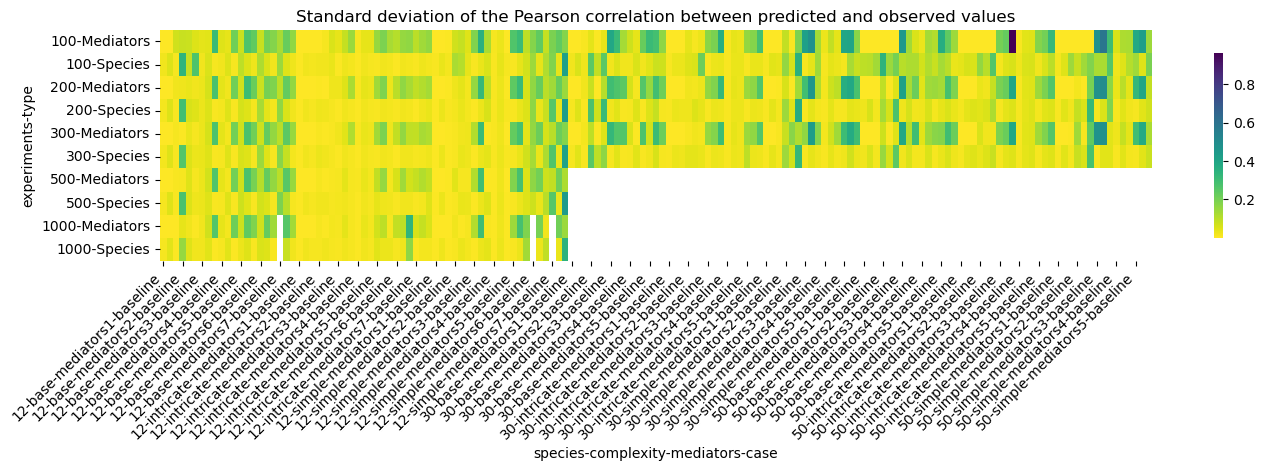

experiments                                 100                 200   \
type                                   Mediators   Species Mediators   
species complexity mediators  case                                     
12      base       mediators1 baseline  0.001401  0.019257  0.001049   
                              noisy     0.000928  0.051757  0.002046   
                              sparse    0.068965  0.012968  0.022167   
                   mediators2 baseline  0.080030  0.337649  0.022781   
                              noisy     0.076067  0.083554  0.031074   
...                                          ...       ...       ...   
50      simple     mediators4 noisy     0.118446  0.045233  0.098033   
                              sparse    0.120564  0.106157  0.039070   
                   mediators5 baseline  0.381700  0.136567  0.319743   
                              noisy     0.427012  0.045946  0.394956   
                              sparse    0.140749  0.194286  0.089532   

experiments                                           300             \
type                                     Species Mediators   Species   
species complexity mediators  case                                     
12      base       mediators1 baseline  0.017507  0.000574  0.015885   
                              noisy     0.048948  0.001294  0.046996   
                              sparse    0.010530  0.013086  0.008936   
                   mediators2 baseline  0.291908  0.004947  0.260930   
                              noisy     0.057687  0.031775  0.049784   
...                                          ...       ...       ...   
50      simple     mediators4 noisy     0.042345  0.086174  0.042093   
                              sparse    0.019292  0.041084  0.016688   
                   mediators5 baseline  0.012075  0.293950  0.013936   
                              noisy     0.042495  0.377731  0.041911   
                              sparse    0.071002  0.122296  0.077869   

experiments                                 500                 1000            
type                                   Mediators   Species Mediators   Species  
species complexity mediators  case                                              
12      base       mediators1 baseline  0.000645  0.013887  0.000156  0.011936  
                              noisy     0.000905  0.045255  0.001009  0.044650  
                              sparse    0.008109  0.007865  0.003747  0.006837  
                   mediators2 baseline  0.012214  0.276590  0.037087  0.151921  
                              noisy     0.047451  0.051005  0.021157  0.045620  
...                                          ...       ...       ...       ...  
50      simple     mediators4 noisy          NaN       NaN       NaN       NaN  
                              sparse         NaN       NaN       NaN       NaN  
                   mediators5 baseline       NaN       NaN       NaN       NaN  
                              noisy          NaN       NaN       NaN       NaN  
                              sparse         NaN       NaN       NaN       NaN  

[153 rows x 10 columns]

In [52]:
import numpy as np
import itertools
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
from scipy.stats import linregress, pearsonr, spearmanr, norm
from sklearn.metrics import roc_curve, auc
import time
import distinctipy

from glob import glob
import re

import pickle as pkl
import sys
import os
import gc

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)
from nsm.nsm import *

# params = {'legend.fontsize': 15,
#           'figure.figsize': (7, 7),
#           'axes.labelsize': 20,
#           'axes.titlesize': 20,
#           'axes.linewidth': 3,
#           'xtick.labelsize': 18,
#           'ytick.labelsize': 18,
#           'svg.fonttype': 'none'}
# plt.rcParams.update(params)
np.random.seed(12345)

mediators_ = {
    'mediators1': ['R01'],
    'mediators2': ['R09'],
    'mediators3': ['R01', 'R05'],
    'mediators4': ['R01', 'R13'],
    'mediators5': ['R01', 'R03', 'R07', 'R10', 'R13'],
    'mediators6': ['R01', 'R03', 'R05', 'R07', 'R08', 'R09', 'R10', 'R12', 'R13', 'R15'],
    'mediators7': ['R01', 'R02', 'R03', 'R04', 'R05', 'R06', 'R07', 'R08', 'R09', 'R10', 'R11', 'R12', 'R13', 'R14', 'R15']
}

col_names = [
    'species',
    'resources',
    'complexity',
    'mediators',
    'case',
    'experiments',
    'k',
    'variable',
    'type',
    'correlation'
]

correlations = pd.read_csv('correlations.csv', header=None, names=col_names, index_col=False)
correlations['type'] = correlations['type'].replace({'S': 'Species', 'R': 'Mediators'})
correlations.drop(['resources', 'k'], axis=1, inplace=True)
correlations = correlations.groupby(['species', 'complexity', 'mediators', 'case', 'experiments', 'type'])['correlation'].std().reset_index()

correlations_pivot = correlations.pivot_table(index=['species', 'complexity', 'mediators', 'case'], columns=['experiments', 'type'], values='correlation').T
plt.figure(figsize=(16, 3))
sns.heatmap(
    correlations_pivot,
    cmap='viridis_r',
    cbar_kws={"shrink": .8},
)
plt.title('Standard deviation of the Pearson correlation between predicted and observed values')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()
correlations_pivot.T

### Procrustes

In [3]:
# import numpy as np
# import itertools
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# import scipy as sp
# from scipy.stats import linregress, pearsonr, spearmanr, norm
# from sklearn.metrics import roc_curve, auc
# import time
# import distinctipy

# from glob import glob
# import re

# import pickle as pkl
# import sys
# import os
# import gc

# current_dir = os.getcwd()
# parent_dir = os.path.dirname(current_dir)
# sys.path.append(parent_dir)
# from nsm.nsm import *

# params = {'legend.fontsize': 15,
#           'figure.figsize': (7, 7),
#           'axes.labelsize': 20,
#           'axes.titlesize': 20,
#           'axes.linewidth': 3,
#           'xtick.labelsize': 18,
#           'ytick.labelsize': 18,
#           'svg.fonttype': 'none'}
# plt.rcParams.update(params)
# np.random.seed(12345)

# mediators_ = {
#     'mediators1': ['R01'],
#     'mediators2': ['R09'],
#     'mediators3': ['R01', 'R05'],
#     'mediators4': ['R01', 'R13'],
#     'mediators5': ['R01', 'R03', 'R07', 'R10', 'R13'],
#     'mediators6': ['R01', 'R03', 'R05', 'R07', 'R08', 'R09', 'R10', 'R12', 'R13', 'R15'],
#     'mediators7': ['R01', 'R02', 'R03', 'R04', 'R05', 'R06', 'R07', 'R08', 'R09', 'R10', 'R11', 'R12', 'R13', 'R14', 'R15']
# }

# col_names = [
#     'species',
#     'resources',
#     'complexity',
#     'mediators',
#     'case',
#     'experiments',
#     'k',
#     'type',
#     'correlation'
# ]

# # Ensure the file exists
# if not os.path.exists('parameters_procrustes.csv'):
#     raise FileNotFoundError("The file 'parameters_procrustes.csv' does not exist in the current directory.")

# correlations = pd.read_csv('parameters_procrustes.csv', header=None, names=col_names)

# for var_type in ['Consumption', 'Production']:
#     for species_num in [12, 30, 50]:
#         for complexity in ['base', 'simple', 'intricate']:
#             # for md in ['mediators1', 'mediators2', 'mediators3', 'mediators4', 'mediators5', 'mediators6', 'mediators7']:
#             to_plot = correlations[
#                 (correlations['species'] == species_num) &
#                 (correlations['complexity'] == complexity) &
#                 (correlations['type'] == var_type)
#             ].copy()
#             if to_plot.empty:
#                 print(f"No data for species {species_num}, variable type {var_type}, complexity {complexity}.")
#                 continue
#             g = sns.relplot(
#                 data=to_plot,
#                 x='experiments',
#                 y='correlation',
#                 hue='mediators',
#                 # style='k',
#                 # dashes=[(1, 0)],
#                 palette='Set1',
#                 col='case',
#                 col_order=['baseline', 'sparse', 'noisy'],
#                 kind='line',
#             )

#             # Include supertitle
#             g.fig.suptitle(
#                 # f'{species_num} species | {md} | {complexity} complexity | variable type: {"Species" if var_type == "S" else "Mediators"}',
#                 f'{species_num} species | {complexity} complexity | parameter type: {var_type}',
#                 fontsize=24,
#                 y=1.05,
#             )

#             # Customize column labels
#             g.set_titles(col_template="{col_name}")
#             g.set_axis_labels('# experiments', 'Procrustes distance')

#             # Save the plot
#             # plot_filename = f'plots/performance/correlation_{species_num}s_{complexity}_{md}_{var_type}.png'
#             plot_filename = f'plots/performance/parameters_disp_{species_num}s_{complexity}_{var_type}.png'
#             os.makedirs(os.path.dirname(plot_filename), exist_ok=True)
#             g.savefig(plot_filename, dpi=300, bbox_inches='tight')
#             plt.close()

#             # Clean up
#             del g
#             gc.collect()

In [22]:
import numpy as np
import itertools
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
from scipy.stats import linregress, pearsonr, spearmanr, norm
from sklearn.metrics import roc_curve, auc
import time
import distinctipy

from glob import glob
import re

import pickle as pkl
import sys
import os
import gc

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)
from nsm.nsm import *

params = {'legend.fontsize': 15,
          'figure.figsize': (7, 7),
          'axes.labelsize': 20,
          'axes.titlesize': 20,
          'axes.linewidth': 3,
          'xtick.labelsize': 18,
          'ytick.labelsize': 18,
          'svg.fonttype': 'none'}
plt.rcParams.update(params)
np.random.seed(12345)

mediators_ = {
    'mediators1': ['R01'],
    'mediators2': ['R09'],
    'mediators3': ['R01', 'R05'],
    'mediators4': ['R01', 'R13'],
    'mediators5': ['R01', 'R03', 'R07', 'R10', 'R13'],
    'mediators6': ['R01', 'R03', 'R05', 'R07', 'R08', 'R09', 'R10', 'R12', 'R13', 'R15'],
    'mediators7': ['R01', 'R02', 'R03', 'R04', 'R05', 'R06', 'R07', 'R08', 'R09', 'R10', 'R11', 'R12', 'R13', 'R14', 'R15']
}

col_names = [
    'species',
    'resources',
    'complexity',
    'mediators',
    'case',
    'experiments',
    'k',
    'type',
    'correlation'
]

# Ensure the file exists
if not os.path.exists('parameters_jsd.csv'):
    raise FileNotFoundError("The file 'parameters_jsd.csv' does not exist in the current directory.")

jsds = pd.read_csv('parameters_jsd.csv', header=None, names=col_names, index_col=False)
# remove duplicated rows
jsds = jsds.drop_duplicates()

for var_type in ['Consumption', 'Production']:
    for species_num in [12, 30, 50]:
        for complexity in ['base', 'simple', 'intricate']:
            # for md in ['mediators1', 'mediators2', 'mediators3', 'mediators4', 'mediators5', 'mediators6', 'mediators7']:
            to_plot = jsds[
                (jsds['species'] == species_num) &
                (jsds['complexity'] == complexity) &
                (jsds['type'] == var_type)
            ].copy()
            if to_plot.empty:
                print(f"No data for species {species_num}, variable type {var_type}, complexity {complexity}.")
                continue
            g = sns.relplot(
                data=to_plot,
                x='experiments',
                y='correlation',
                hue='mediators',
                # style='k',
                # dashes=[(1, 0)],
                palette='Set1',
                col='case',
                col_order=['baseline', 'sparse', 'noisy'],
                kind='line',
            )

            # Include supertitle
            g.fig.suptitle(
                # f'{species_num} species | {md} | {complexity} complexity | variable type: {"Species" if var_type == "S" else "Mediators"}',
                f'{species_num} species | {complexity} complexity | parameter type: {var_type}',
                fontsize=24,
                y=1.05,
            )

            # Customize column labels
            g.set_titles(col_template="{col_name}")
            g.set_axis_labels('# experiments', 'Jensen-Shannon Distance')

            # Save the plot
            # plot_filename = f'plots/performance/correlation_{species_num}s_{complexity}_{md}_{var_type}.png'
            plot_filename = f'plots/performance/parameters/jsd_{species_num}s_{complexity}_{var_type}.png'
            os.makedirs(os.path.dirname(plot_filename), exist_ok=True)
            g.savefig(plot_filename, dpi=300, bbox_inches='tight')
            plt.close()

            # Clean up
            del g
            gc.collect()

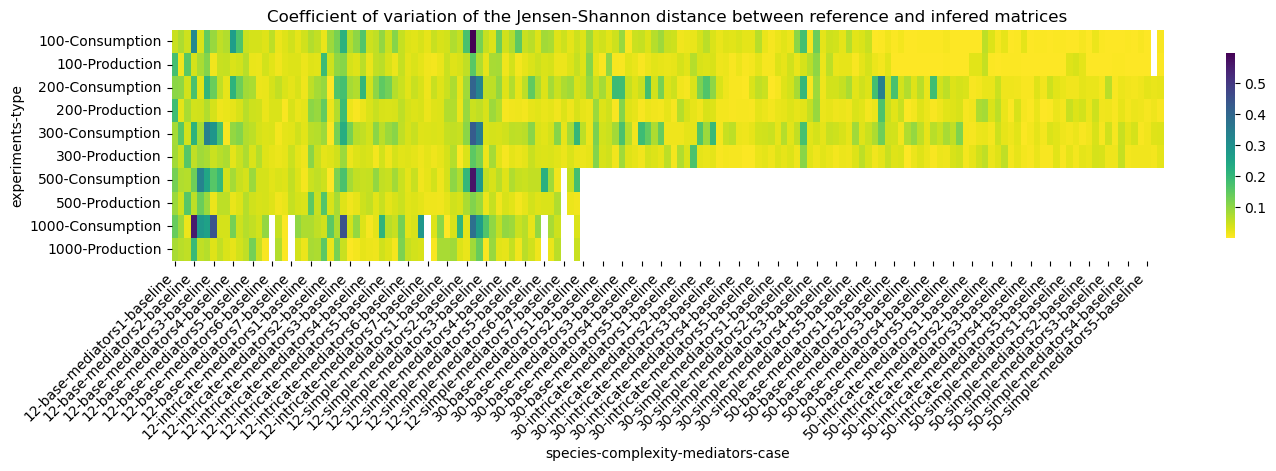

experiments                                   100                    200   \
type                                   Consumption Production Consumption   
species complexity mediators  case                                          
12      base       mediators1 baseline    0.050779   0.178330    0.103295   
                              noisy       0.073769   0.011965    0.098522   
                              sparse      0.045532   0.156056    0.039816   
                   mediators2 baseline    0.315076   0.039295    0.171360   
                              noisy       0.033041   0.076119    0.027101   
...                                            ...        ...         ...   
50      simple     mediators4 noisy       0.001376   0.001617    0.011361   
                              sparse      0.005274   0.001111    0.016134   
                   mediators5 baseline    0.001578   0.000333    0.025700   
                              noisy            NaN        NaN    0.018998   
                              sparse      0.006819   0.002786    0.022397   

experiments                                              300              \
type                                   Production Consumption Production   
species complexity mediators  case                                         
12      base       mediators1 baseline   0.182614    0.079865   0.083328   
                              noisy      0.024527    0.155118   0.047675   
                              sparse     0.075050    0.040981   0.158078   
                   mediators2 baseline   0.040749    0.211095   0.057056   
                              noisy      0.044236    0.080795   0.086088   
...                                           ...         ...        ...   
50      simple     mediators4 noisy      0.018522    0.039696   0.013387   
                              sparse     0.015286    0.006244   0.012921   
                   mediators5 baseline   0.009495    0.012598   0.012123   
                              noisy      0.016200    0.028577   0.009903   
                              sparse     0.006103    0.030958   0.024089   

experiments                                   500                    1000  \
type                                   Consumption Production Consumption   
species complexity mediators  case                                          
12      base       mediators1 baseline    0.125670   0.089535    0.138204   
                              noisy       0.071681   0.045658    0.086409   
                              sparse      0.065552   0.157211    0.017100   
                   mediators2 baseline    0.132709   0.060439    0.553586   
                              noisy       0.329397   0.137093    0.276837   
...                                            ...        ...         ...   
50      simple     mediators4 noisy            NaN        NaN         NaN   
                              sparse           NaN        NaN         NaN   
                   mediators5 baseline         NaN        NaN         NaN   
                              noisy            NaN        NaN         NaN   
                              sparse           NaN        NaN         NaN   

experiments                                        
type                                   Production  
species complexity mediators  case                 
12      base       mediators1 baseline   0.078623  
                              noisy      0.064735  
                              sparse     0.058052  
                   mediators2 baseline   0.191866  
                              noisy      0.057077  
...                                           ...  
50      simple     mediators4 noisy           NaN  
                              sparse          NaN  
                   mediators5 baseline        NaN  
                              noisy           NaN  
                              sparse          NaN  

[153 rows x 10 columns]

In [59]:
import numpy as np
import itertools
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
from scipy.stats import linregress, pearsonr, spearmanr, norm
from sklearn.metrics import roc_curve, auc
import time
import distinctipy

from glob import glob
import re

import pickle as pkl
import sys
import os
import gc

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)
from nsm.nsm import *

# params = {'legend.fontsize': 15,
#           'figure.figsize': (7, 7),
#           'axes.labelsize': 20,
#           'axes.titlesize': 20,
#           'axes.linewidth': 3,
#           'xtick.labelsize': 18,
#           'ytick.labelsize': 18,
#           'svg.fonttype': 'none'}
# plt.rcParams.update(params)
np.random.seed(12345)

mediators_ = {
    'mediators1': ['R01'],
    'mediators2': ['R09'],
    'mediators3': ['R01', 'R05'],
    'mediators4': ['R01', 'R13'],
    'mediators5': ['R01', 'R03', 'R07', 'R10', 'R13'],
    'mediators6': ['R01', 'R03', 'R05', 'R07', 'R08', 'R09', 'R10', 'R12', 'R13', 'R15'],
    'mediators7': ['R01', 'R02', 'R03', 'R04', 'R05', 'R06', 'R07', 'R08', 'R09', 'R10', 'R11', 'R12', 'R13', 'R14', 'R15']
}

col_names = [
    'species',
    'resources',
    'complexity',
    'mediators',
    'case',
    'experiments',
    'k',
    'type',
    'jsd'
]

jds = pd.read_csv('parameters_jsd.csv', header=None, names=col_names, index_col=False)
jds.drop(['resources', 'k'], axis=1, inplace=True)
jds = jds.groupby(['species', 'complexity', 'mediators', 'case', 'experiments', 'type']).agg(
    mean_jsd=('jsd', 'mean'),
    std_jsd=('jsd', 'std')
).reset_index()
jds['cv_jsd'] = jds['std_jsd'] / jds['mean_jsd']

jds_pivot = jds.pivot_table(index=['species', 'complexity', 'mediators', 'case'], columns=['experiments', 'type'], values='cv_jsd').T
plt.figure(figsize=(16, 3))
sns.heatmap(
    jds_pivot,
    cmap='viridis_r',
    cbar_kws={"shrink": .8},
)
plt.title('Coefficient of variation of the Jensen-Shannon distance between reference and infered matrices')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()
jds_pivot.T

### Parameter Correlations

In [24]:
import numpy as np
import itertools
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
from scipy.stats import linregress, pearsonr, spearmanr, norm
from sklearn.metrics import roc_curve, auc
import time
import distinctipy

from glob import glob
import re

import pickle as pkl
import sys
import os
import gc

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)
from nsm.nsm import *

params = {'legend.fontsize': 15,
          'figure.figsize': (7, 7),
          'axes.labelsize': 20,
          'axes.titlesize': 20,
          'axes.linewidth': 3,
          'xtick.labelsize': 18,
          'ytick.labelsize': 18,
          'svg.fonttype': 'none'}
plt.rcParams.update(params)
np.random.seed(12345)

mediators_ = {
    'mediators1': ['R01'],
    'mediators2': ['R09'],
    'mediators3': ['R01', 'R05'],
    'mediators4': ['R01', 'R13'],
    'mediators5': ['R01', 'R03', 'R07', 'R10', 'R13'],
    'mediators6': ['R01', 'R03', 'R05', 'R07', 'R08', 'R09', 'R10', 'R12', 'R13', 'R15'],
    'mediators7': ['R01', 'R02', 'R03', 'R04', 'R05', 'R06', 'R07', 'R08', 'R09', 'R10', 'R11', 'R12', 'R13', 'R14', 'R15']
}

col_names = [
    'species',
    'resources',
    'complexity',
    'mediators',
    'case',
    'experiments',
    'k',
    'variable',
    'type',
    'correlation'
]

# Ensure the file exists
if not os.path.exists('parameters_correlations.csv'):
    raise FileNotFoundError("The file 'parameters_correlations.csv' does not exist in the current directory.")

correlations = pd.read_csv('parameters_correlations.csv', header=None, names=col_names, index_col=False)
# remove duplicated rows
correlations = correlations.drop_duplicates()

# for var_type in ['Consumption', 'Production']:
for var_type in ['Consumption']:
    for species_num in [12, 30, 50]:
        for complexity in ['base', 'simple', 'intricate']:
            # for md in ['mediators1', 'mediators2', 'mediators3', 'mediators4', 'mediators5', 'mediators6', 'mediators7']:
            to_plot = correlations[
                (correlations['species'] == species_num) &
                (correlations['complexity'] == complexity) &
                (correlations['type'] == var_type)
            ].copy()
            if to_plot.empty:
                print(f"No data for species {species_num}, variable type {var_type}, complexity {complexity}.")
                continue
            g = sns.relplot(
                data=to_plot,
                x='experiments',
                y='correlation',
                hue='mediators',
                # style='k',
                # dashes=[(1, 0)],
                palette='Set1',
                col='case',
                col_order=['baseline', 'sparse', 'noisy'],
                kind='line',
            )

            # Include supertitle
            g.fig.suptitle(
                # f'{species_num} species | {md} | {complexity} complexity | variable type: {"Species" if var_type == "S" else "Mediators"}',
                f'{species_num} species | {complexity} complexity | parameter type: {var_type}',
                fontsize=24,
                y=1.05,
            )

            # Customize column labels
            g.set_titles(col_template="{col_name}")
            g.set_axis_labels('# experiments', 'Spearman correlation ($\\rho$)')

            # Save the plot
            # plot_filename = f'plots/performance/correlation_{species_num}s_{complexity}_{md}_{var_type}.png'
            plot_filename = f'plots/performance/parameters/correlations_{species_num}s_{complexity}_{var_type}.png'
            os.makedirs(os.path.dirname(plot_filename), exist_ok=True)
            g.savefig(plot_filename, dpi=300, bbox_inches='tight')
            plt.close()

            # Clean up
            del g
            gc.collect()

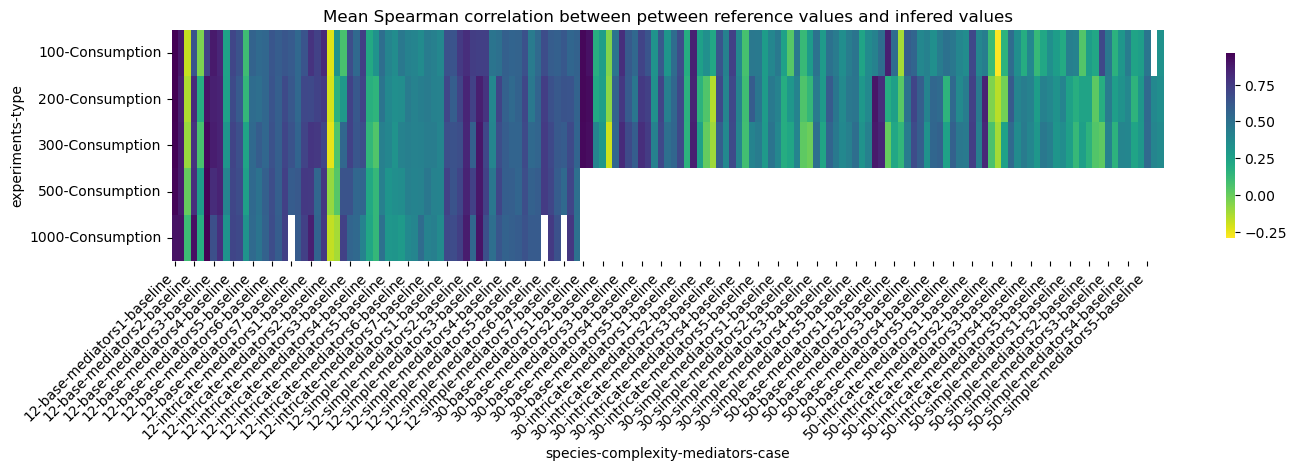

experiments                                   100         200         300   \
type                                   Consumption Consumption Consumption   
species complexity mediators  case                                           
12      base       mediators1 baseline    0.965035    0.960839    0.955245   
                              noisy       0.883916    0.861538    0.875524   
                              sparse     -0.177622   -0.132867   -0.097902   
                   mediators2 baseline    0.638100    0.815028    0.784573   
                              noisy      -0.043507    0.185629    0.073962   
...                                            ...         ...         ...   
50      simple     mediators4 noisy       0.238314    0.152899    0.232995   
                              sparse      0.267930    0.307820    0.299176   
                   mediators5 baseline    0.474011    0.540159    0.534130   
                              noisy            NaN    0.377267    0.394386   
                              sparse      0.331425    0.352104    0.367693   

experiments                                   500         1000  
type                                   Consumption Consumption  
species complexity mediators  case                              
12      base       mediators1 baseline    0.946853    0.904429  
                              noisy       0.869930    0.902098  
                              sparse      0.008392    0.107226  
                   mediators2 baseline    0.799075    0.911226  
                              noisy       0.274093    0.183695  
...                                            ...         ...  
50      simple     mediators4 noisy            NaN         NaN  
                              sparse           NaN         NaN  
                   mediators5 baseline         NaN         NaN  
                              noisy            NaN         NaN  
                              sparse           NaN         NaN  

[153 rows x 5 columns]

In [65]:
import numpy as np
import itertools
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
from scipy.stats import linregress, pearsonr, spearmanr, norm
from sklearn.metrics import roc_curve, auc
import time
import distinctipy

from glob import glob
import re

import pickle as pkl
import sys
import os
import gc

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)
from nsm.nsm import *

# params = {'legend.fontsize': 15,
#           'figure.figsize': (7, 7),
#           'axes.labelsize': 20,
#           'axes.titlesize': 20,
#           'axes.linewidth': 3,
#           'xtick.labelsize': 18,
#           'ytick.labelsize': 18,
#           'svg.fonttype': 'none'}
# plt.rcParams.update(params)
np.random.seed(12345)

mediators_ = {
    'mediators1': ['R01'],
    'mediators2': ['R09'],
    'mediators3': ['R01', 'R05'],
    'mediators4': ['R01', 'R13'],
    'mediators5': ['R01', 'R03', 'R07', 'R10', 'R13'],
    'mediators6': ['R01', 'R03', 'R05', 'R07', 'R08', 'R09', 'R10', 'R12', 'R13', 'R15'],
    'mediators7': ['R01', 'R02', 'R03', 'R04', 'R05', 'R06', 'R07', 'R08', 'R09', 'R10', 'R11', 'R12', 'R13', 'R14', 'R15']
}

col_names = [
    'species',
    'resources',
    'complexity',
    'mediators',
    'case',
    'experiments',
    'k',
    'variable',
    'type',
    'correlation'
]

correlations = pd.read_csv('parameters_correlations.csv', header=None, names=col_names, index_col=False)
correlations.drop(['resources', 'k'], axis=1, inplace=True)
correlations = correlations.groupby(['species', 'complexity', 'mediators', 'case', 'experiments', 'type'])['correlation'].mean().reset_index()

correlations_pivot = correlations.pivot_table(index=['species', 'complexity', 'mediators', 'case'], columns=['experiments', 'type'], values='correlation').T
plt.figure(figsize=(16, 3))
sns.heatmap(
    correlations_pivot,
    cmap='viridis_r',
    cbar_kws={"shrink": .8},
)
plt.title('Mean Spearman correlation between petween reference values and infered values')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()
correlations_pivot.T

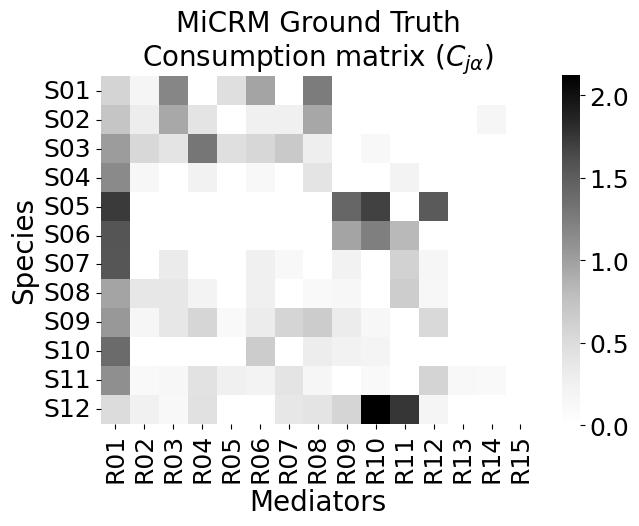

In [29]:
fig, ax = plt.subplots()
C_iα = pd.read_csv('/home/acs98/Documents/Venturelli-lab/nsm-scalability/parameters/consumer_preference_12s15r_base.csv', index_col=0)
sp_map = {'S{:01d}'.format(i): 'S{:02d}'.format(i+1) for i in range(12)}
rcs_map = {'R{:01d}'.format(i): 'R{:02d}'.format(i+1) for i in range(15)}
rpl_map = {**sp_map, **rcs_map}
C_iα.columns = C_iα.columns.to_series().replace(rpl_map)
C_iα.index = C_iα.index.to_series().replace(rpl_map)
to_plot = C_iα.copy()
sns.heatmap(to_plot,
                cmap='Greys',
                square=True,
                cbar_kws={"shrink": 0.65},
                ax=ax)
ax.set_title('MiCRM Ground Truth\nConsumption matrix ($C_{j\\alpha}$)')
ax.set_xlabel('Mediators')
ax.set_ylabel('Species')
fig.savefig('consumption_matrix_12_base.png', dpi=300, bbox_inches='tight')

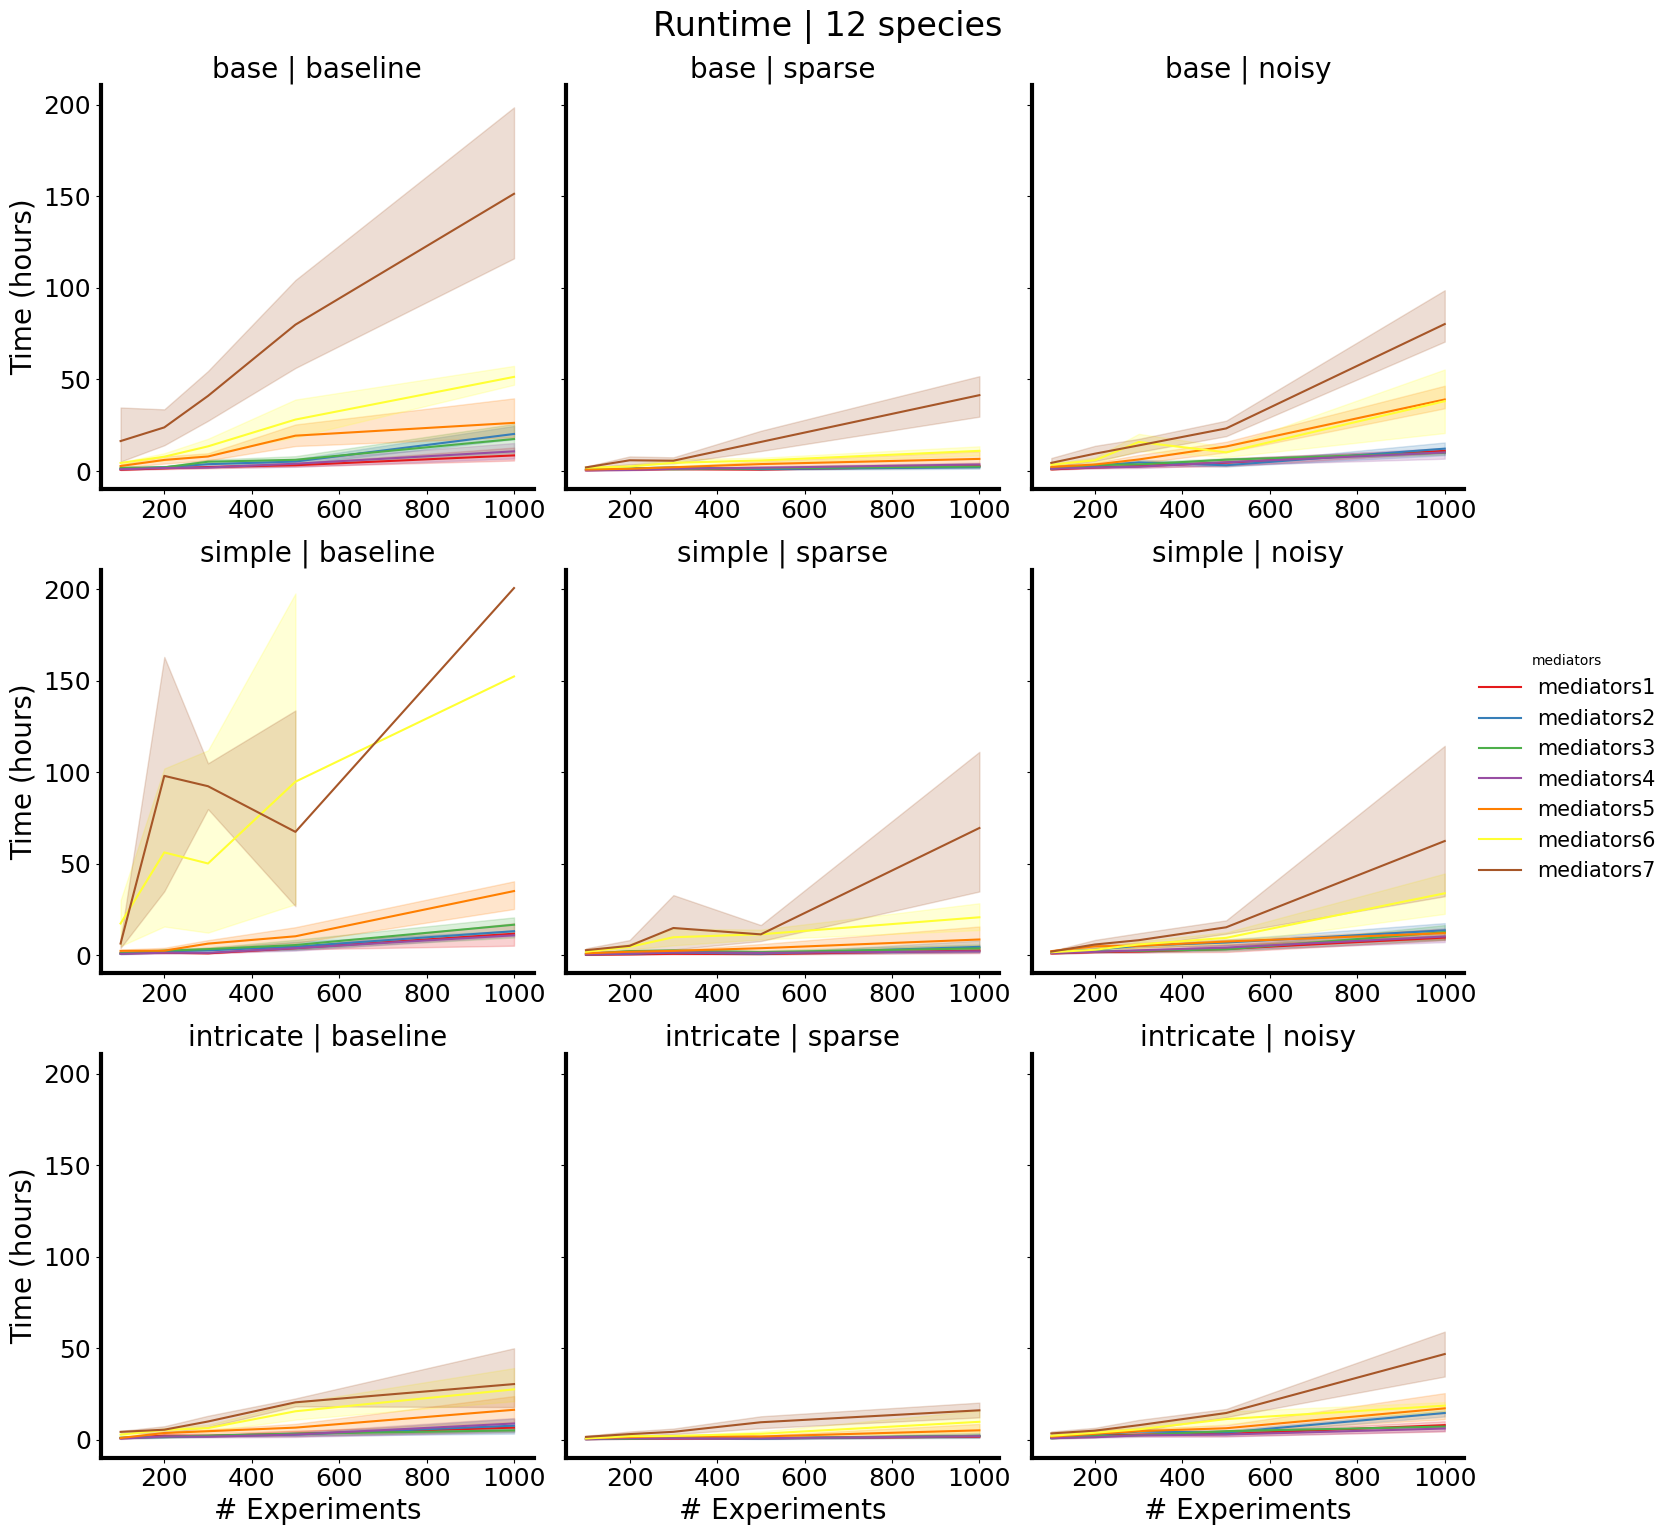

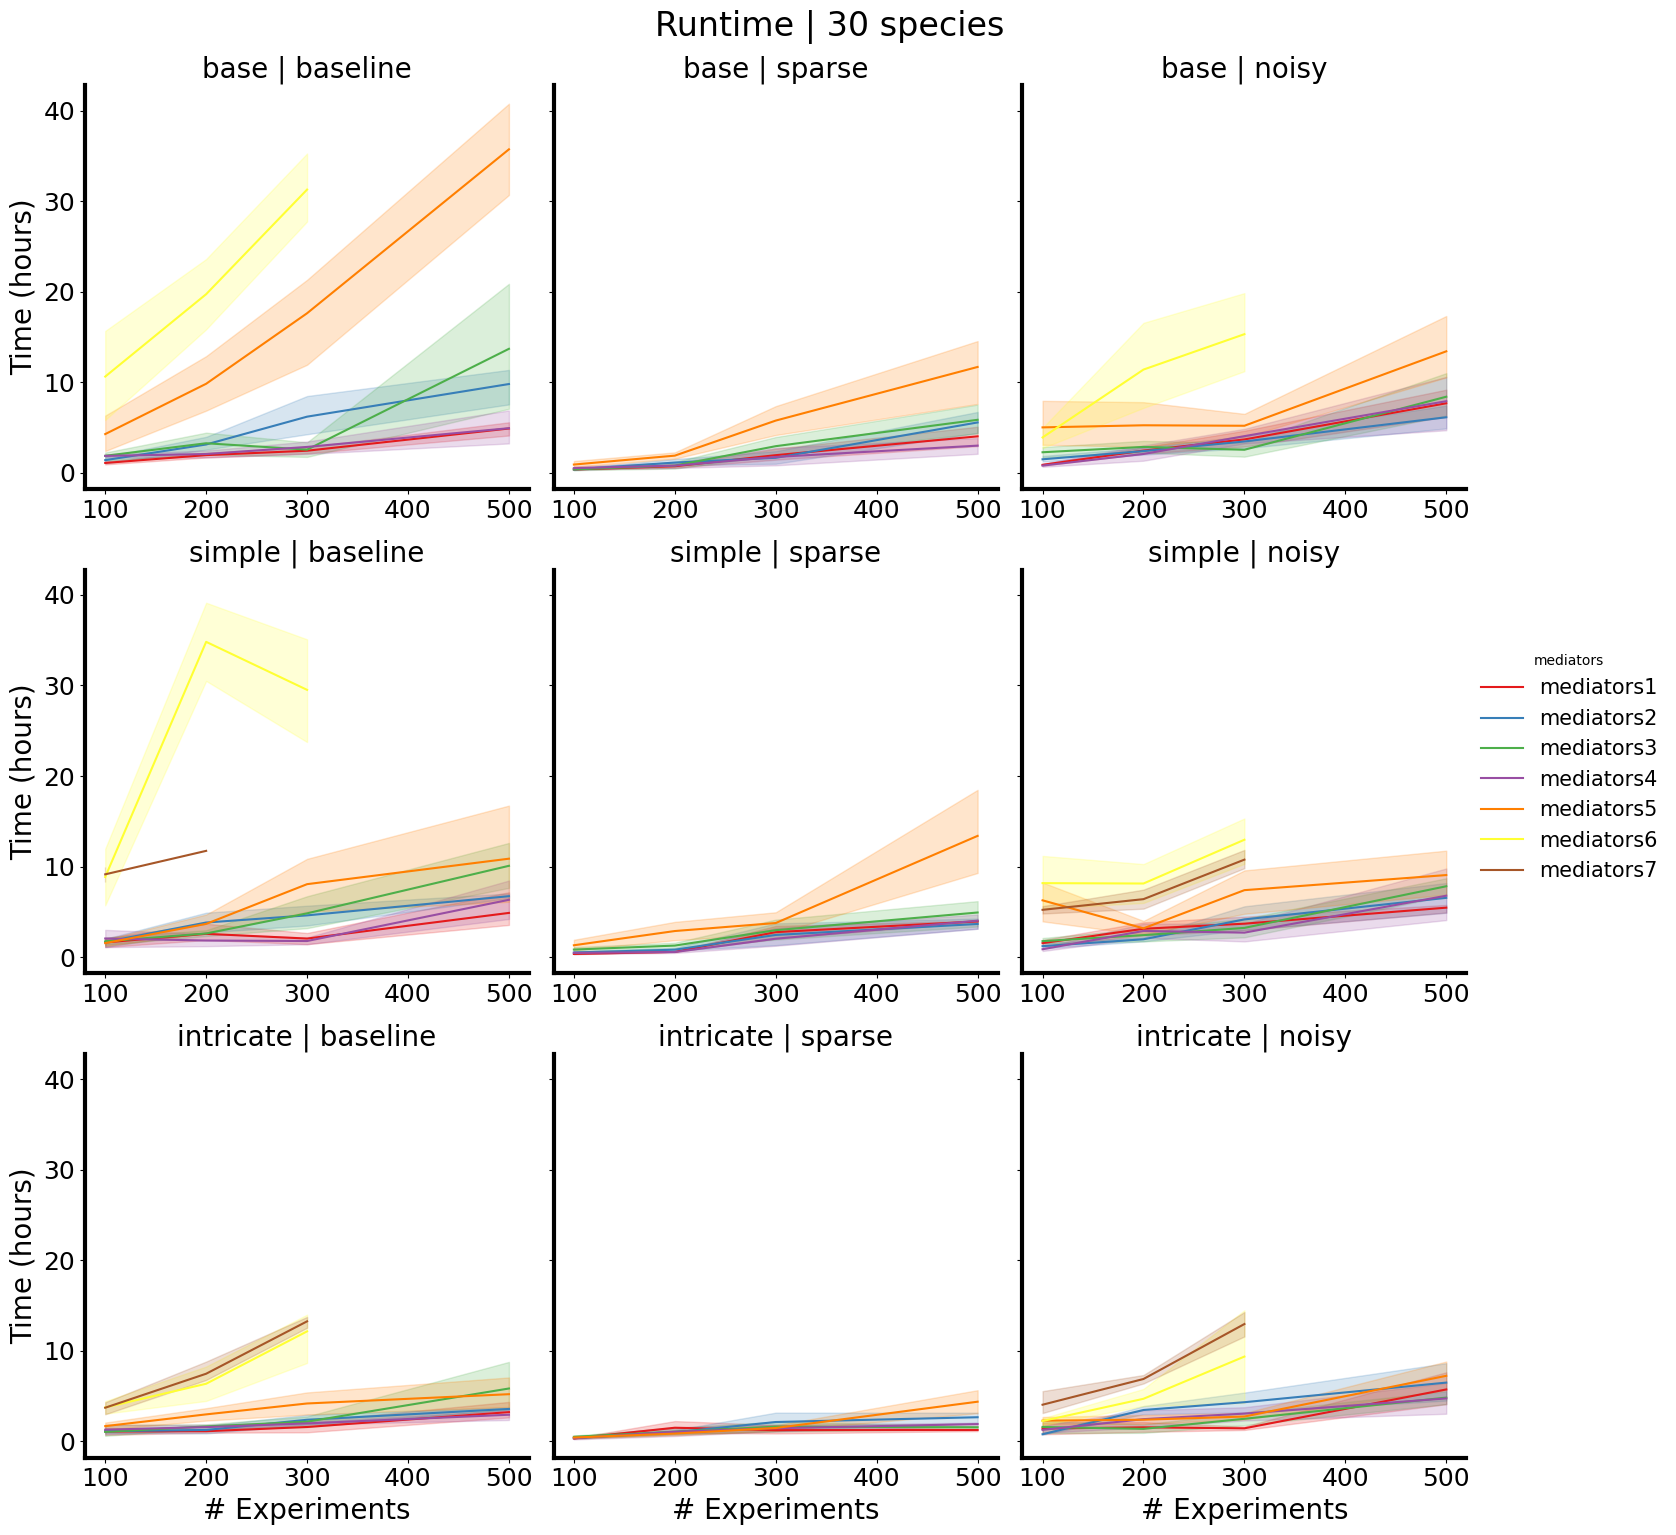

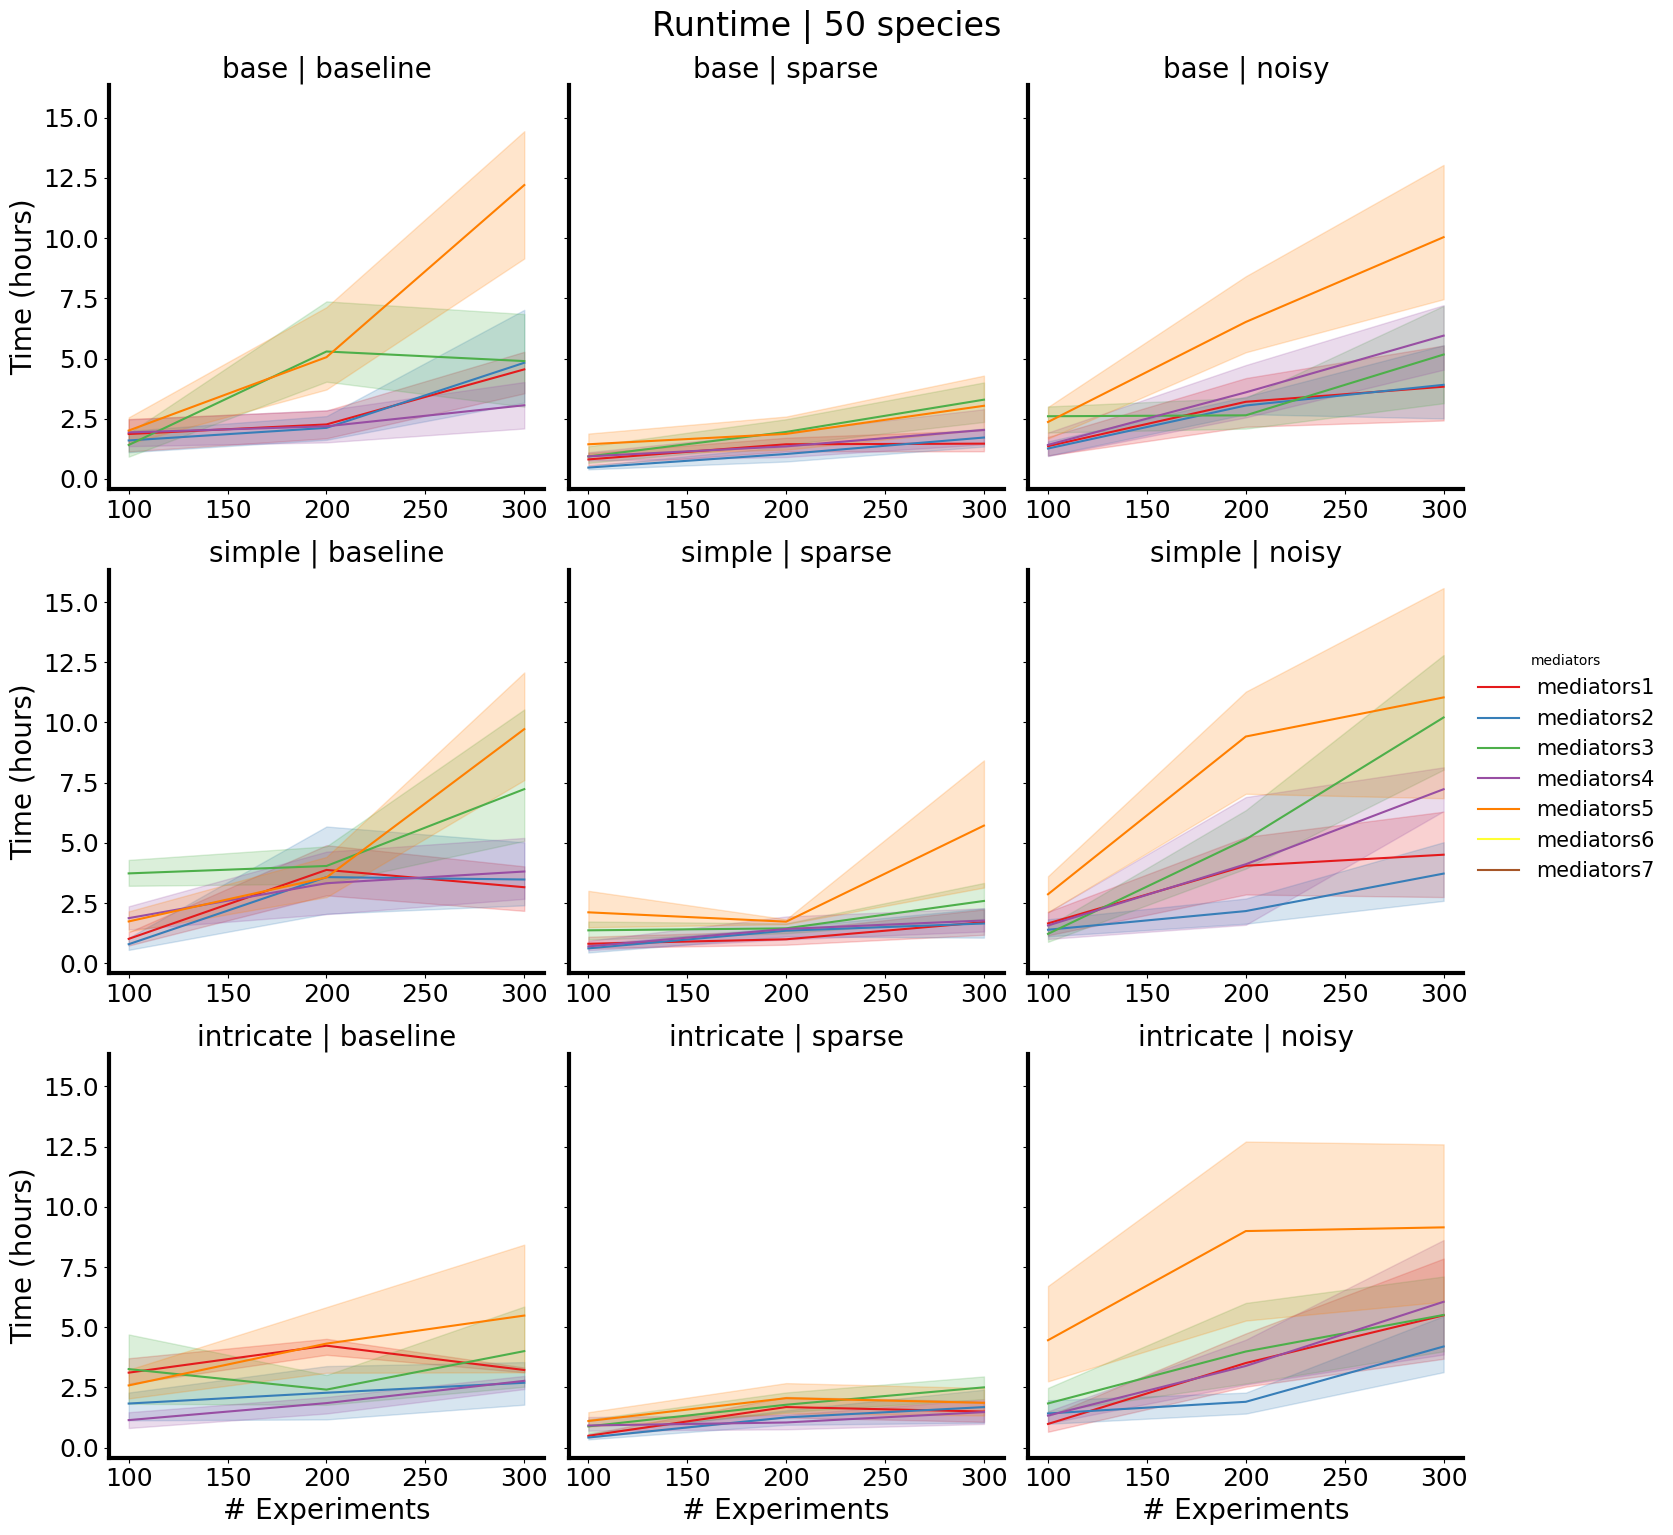

In [ ]:
import glob
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import pickle as pkl
import sys
import os

# Get the current working directory (where the script is run from)
current_dir = os.getcwd()

# Get the parent directory
parent_dir = os.path.dirname(current_dir)

# Add the parent directory to sys.path
sys.path.append(parent_dir)

# set plot parameters
params = {'legend.fontsize': 15,
          'figure.figsize': (7, 7),
          'axes.labelsize': 20,
          'axes.titlesize': 20,
          'axes.linewidth': 3,
          'xtick.labelsize':18,
          'ytick.labelsize':18,
          'xtick.labelsize':18,
          'ytick.labelsize':18,
          'svg.fonttype':'none'}
plt.rcParams.update(params)

outs = glob.glob('logs/outs/*')
errors = [i.replace('.out', '.err').replace('/outs/', '/errors/') for i in outs]
logs = zip(outs, errors)

timerun = {
    'species': [], 
    'resources': [],
    'complexity': [],
    'case': [],  
    'experiments': [], 
    'mediators': [],
    'time': []
    }
failed = []
for out, error in logs:
    # check that the file is not empty
    if os.stat(out).st_size == 0:
        continue
    if os.stat(error).st_size != 0:
        continue
    with open(out) as f:
        lines = f.readlines()
        params = lines[0].split('_')
        
        timerun['species'].append(int(params[1].split('s')[0]))
        timerun['resources'].append(int(params[1].split('s')[1].replace('r', '')))
        timerun['complexity'].append(params[2])
        timerun['case'].append(params[3])
        timerun['experiments'].append(int(params[4].replace('exps', '')))
        timerun['mediators'].append(params[5])
        timerun['time'].append(float(lines[-1].split(': ')[1].replace('s', '')))
timerun = pd.DataFrame(timerun)
timerun['time'] = (((timerun['time'].astype(float) / 60) / 60)).round(2)

for species in [12, 30, 50]:
    to_plot = timerun.copy().loc[timerun['species'] == species]
    g = sns.relplot(x='experiments', 
            y='time', 
            hue='mediators', 
            hue_order=['mediators1',
                       'mediators2', 
                       'mediators3', 
                       'mediators4',
                       'mediators5',
                       'mediators6',
                       'mediators7'],
            palette='Set1',
            col='case',
            col_order=['baseline', 'sparse', 'noisy'],
            row='complexity',
            row_order=['base', 'simple', 'intricate'],
            # style='species',
            kind='line',
            data=to_plot)

    # Increase space between rows
    g.fig.subplots_adjust(hspace=0.2)

    # Include supertitle
    g.fig.suptitle(
        f'Runtime | {species} species',
        fontsize=24,
        y=1.02,
    )

    # Customize column and row labels
    g.set_titles(col_template="{col_name}", row_template="{row_name}")
    g.set_axis_labels('# Experiments', 'Time (hours)')

    # Show x ticks for each row
    for ax in g.axes.flat:
        ax.tick_params(axis='x', which='both', labelbottom=True)

    plt.show()  